# Task 1 - Customer Complaint Topic Discovery & Escalation-Risk Prediction
### LDA topic modelling + Gaussian Process classification (via thresholded regression)

**Module:** STW7085CEM Advanced Machine Learning - Task 1 (Research Paper, 50%).

This notebook runs **top-to-bottom** and reproduces every figure and table used in the paper.
Reusable logic lives in `src/` (`preprocess`, `topics`, `features`, `evaluate`); the cells below
orchestrate it and print each phase's acceptance check.

**Method note (assignment-mandated):** GP classification is done by thresholding a
`GaussianProcessRegressor` output - *not* `GaussianProcessClassifier`. The GP uses a stratified
~10K subsample because a GP is O(n³) and a full GP on the whole corpus is infeasible; LDA and
feature extraction use the full labelled corpus.

**Setup.** Resolve the project root so paths work from any working directory, enable autoreload of
the `src/` modules, import libraries, fix the random seed, and create the output folders.

In [1]:
# Auto-reload the src/ modules so edits to preprocess/topics/features/evaluate take
# effect on re-run without restarting the kernel.
%load_ext autoreload
%autoreload 2

import os, sys, warnings, pickle
from pathlib import Path
warnings.filterwarnings("ignore")

# Resolve the project root no matter what the kernel's working directory is - notebooks/
# under nbconvert, or the workspace root under VS Code both resolve to the same place.
def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    return start
ROOT = _find_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import preprocess as pp
import topics as tp
import features as ft
import evaluate as ev

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG = ROOT / "results" / "figures"
TAB = ROOT / "results" / "tables"
PROC = ROOT / "data" / "processed"
for d in (FIG, TAB, PROC):
    d.mkdir(parents=True, exist_ok=True)
print("project root:", ROOT)
print("ready")

project root: D:\MSc\AML\Assignment
ready


## §B - Load, clean, and build the real-outcome target `y`

`y` is the **recorded company response**, not an invented rule: `1` = closed with
monetary/non-monetary relief, `0` = closed with explanation; untimely / in-progress rows are
dropped. We keep the **full** labelled corpus (no down-sampling).

Load the raw export, apply the cleaning and real-outcome labelling, save the corpus, and report the
class balance and product mix.

In [2]:
df = pp.build_labeled(pp.load_raw())
df.to_pickle(f"{PROC}/corpus.pkl")

bal = pp.class_balance(df)
print(f"Final labelled rows : {bal['n']:,}")
print(f"Positive (relief)   : {bal['positive']:,} ({bal['pct_positive']}%)")
print(f"Negative (explain)  : {bal['negative']:,}")
print("\nProduct mix:\n", df["product"].value_counts())

Final labelled rows : 56,390
Positive (relief)   : 10,021 (17.77%)
Negative (explain)  : 46,369

Product mix:
 product
Debt collection    46048
Mortgage           10342
Name: count, dtype: int64


## §B2 - Exploratory Data Analysis

Before modelling we characterise the corpus along several dimensions.

Quantify the data-cleaning attrition (how many rows each step removes) and check for missing values.

In [3]:
attrition = pp.cleaning_attrition(pp.load_raw())
print("Data-cleaning attrition funnel:")
print(attrition.to_string(index=False))
print("\nMissing values per kept column:")
print(df.isna().sum().to_string())

Data-cleaning attrition funnel:
                         step  rows  dropped
                     Raw rows 70000        0
          Non-empty narrative 70000        0
         After de-duplication 57087    12913
       Narrative >= 10 tokens 56834      253
Labelled (relief/explanation) 56390      444

Missing values per kept column:
date                  0
product               0
subproduct            0
issue                 0
subissue            789
narrative             0
submitted_via         0
company_response      0
timely                0
y                     0


Plot the target class balance, the recorded company-response mix, the product mix, and the
narrative-length distribution.

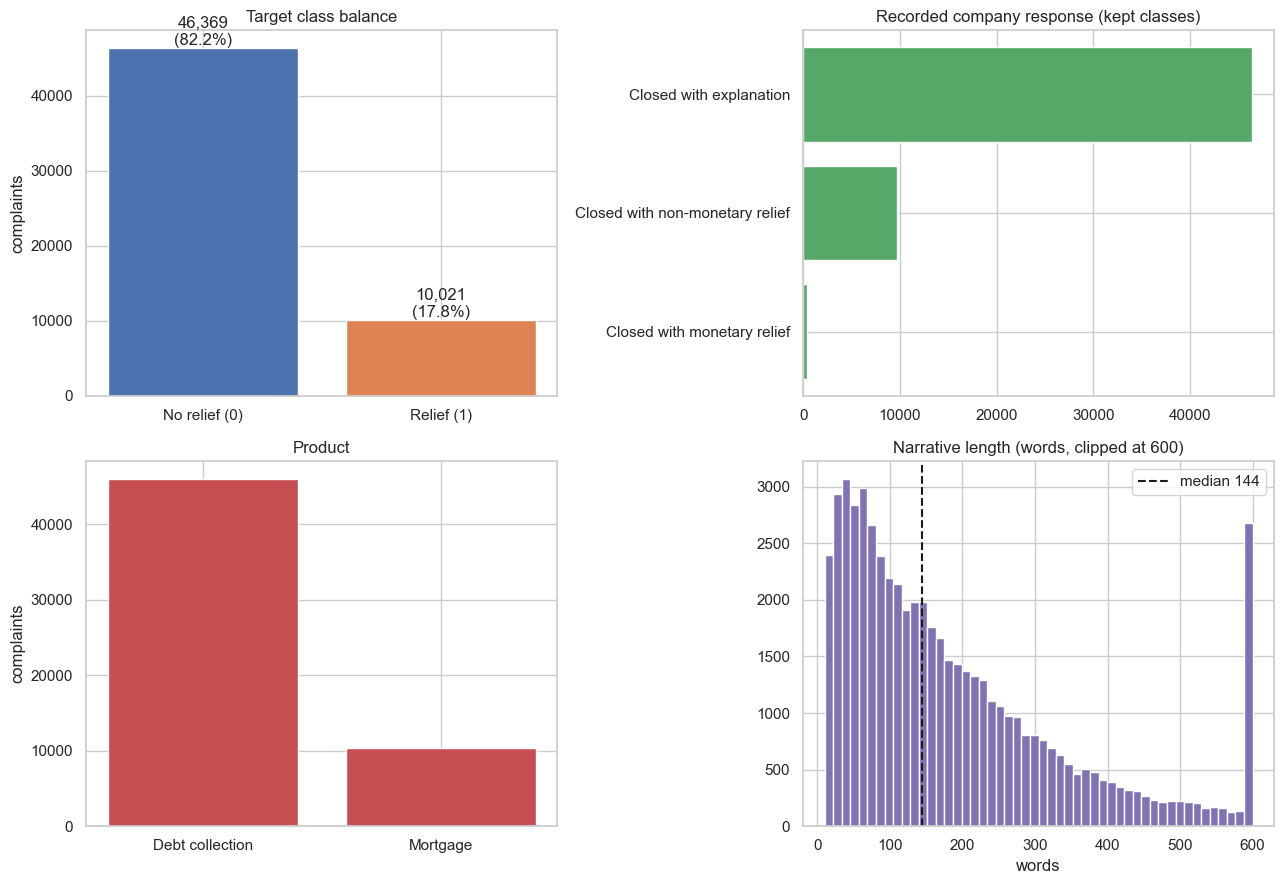

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

vc = df["y"].map({0: "No relief (0)", 1: "Relief (1)"}).value_counts()
ax[0, 0].bar(vc.index, vc.values, color=["#4C72B0", "#DD8452"])
for i, v in enumerate(vc.values):
    ax[0, 0].text(i, v, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", va="bottom")
ax[0, 0].set_title("Target class balance"); ax[0, 0].set_ylabel("complaints")

rc = df["company_response"].value_counts()
ax[0, 1].barh(rc.index[::-1], rc.values[::-1], color="#55A868")
ax[0, 1].set_title("Recorded company response (kept classes)")

pc = df["product"].value_counts()
ax[1, 0].bar(pc.index, pc.values, color="#C44E52")
ax[1, 0].set_title("Product"); ax[1, 0].set_ylabel("complaints")

nlen = df["narrative"].str.split().str.len()
ax[1, 1].hist(nlen.clip(upper=600), bins=50, color="#8172B3")
ax[1, 1].axvline(nlen.median(), color="k", ls="--", label=f"median {nlen.median():.0f}")
ax[1, 1].set_title("Narrative length (words, clipped at 600)")
ax[1, 1].set_xlabel("words"); ax[1, 1].legend()

fig.tight_layout(); fig.savefig(FIG / "eda_overview.png", dpi=150); plt.show()

Track how monthly complaint volume and the relief rate evolve over time.

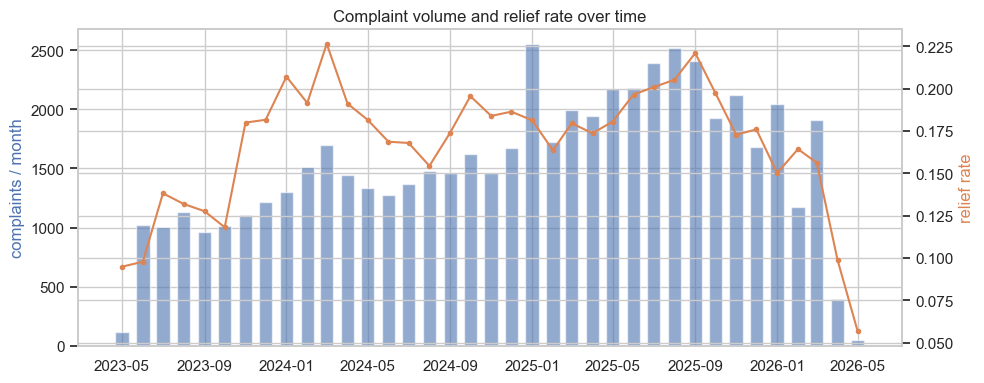

Monthly relief rate ranges 0.057-0.226


In [5]:
# Temporal trend: monthly complaint volume and relief rate
dt = pd.to_datetime(df["date"], errors="coerce")
monthly = (df.assign(month=dt.dt.to_period("M").dt.to_timestamp())
             .groupby("month").agg(volume=("y", "size"), relief_rate=("y", "mean")))
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(monthly.index, monthly["volume"], width=20, color="#4C72B0", alpha=.6)
ax1.set_ylabel("complaints / month", color="#4C72B0")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["relief_rate"], "o-", color="#DD8452", ms=3)
ax2.set_ylabel("relief rate", color="#DD8452")
ax1.set_title("Complaint volume and relief rate over time")
fig.tight_layout(); fig.savefig(FIG / "eda_temporal.png", dpi=150); plt.show()
print("Monthly relief rate ranges {:.3f}-{:.3f}".format(
    monthly["relief_rate"].min(), monthly["relief_rate"].max()))

## §C - Text preprocessing

Turn the raw narratives into clean token lists for topic modelling and feature extraction.

Lowercase, strip `XXXX`/`XX` redaction tokens, keep alpha tokens (len ≥ 3), remove stopwords and
lemmatise; complaint-salient words (*account, payment, refund, dispute, fee*) are kept. Then report
vocabulary size, mean length, and three sample cleaned documents.

In [6]:
tokens = pp.preprocess_corpus(df["narrative"].tolist())
lens = np.array([len(t) for t in tokens])
vocab_raw = len({t for doc in tokens for t in doc})

print(f"Raw vocabulary (pre-filter): {vocab_raw:,}")
print(f"Mean tokens/doc           : {lens.mean():.1f}  (median {np.median(lens):.0f})")
print("\nThree sample cleaned docs:")
for i in (0, 1, 2):
    print(f"  [{i}] {' '.join(tokens[i][:30])} ...")

Raw vocabulary (pre-filter): 32,709
Mean tokens/doc           : 92.7  (median 63)

Three sample cleaned docs:
  [0] amount collect accurate credit report called lawsuit pay debt amount right rep email correspondence gotten reply back ...
  [1] imperial finance corp attempting contact wife made debt called texted emailed repeatedly email several unknown personal email address copied spamming random people website imperialfinancecorp com appears existed since website highly ...
  [2] done business know debt like copy contract say owe debt ...


## §D - LDA topic modelling

Discover interpretable topics and choose the number of topics K in a principled way.

Build the gensim dictionary and bag-of-words corpus, fit LDA for **K ∈ {5,10,15,20}**, and select K
by **c_v coherence** (held-out perplexity is reported alongside).

In [7]:
dictionary, corpus = tp.build_dictionary_corpus(tokens)
print(f"Filtered vocabulary: {len(dictionary):,} terms")

sel, models = tp.select_k(dictionary, corpus, tokens, k_values=(5, 10, 15, 20), passes=5)
sel.to_csv(f"{TAB}/lda_selection.csv", index=False)
print(sel.to_string(index=False))

K = int(sel.sort_values("coherence_cv", ascending=False).iloc[0]["k"])
print(f"\nChosen K = {K}  (highest c_v coherence)")

Filtered vocabulary: 7,938 terms
  [LDA 1/4] fitting K=5 on 50,751 docs ...
  [LDA 1/4] K=5 done: c_v=0.596  (104s)
  [LDA 2/4] fitting K=10 on 50,751 docs ...
  [LDA 2/4] K=10 done: c_v=0.556  (320s)
  [LDA 3/4] fitting K=15 on 50,751 docs ...
  [LDA 3/4] K=15 done: c_v=0.537  (154s)
  [LDA 4/4] fitting K=20 on 50,751 docs ...
  [LDA 4/4] K=20 done: c_v=0.528  (164s)
 k  coherence_cv  log_perplexity  perplexity
 5      0.595769       -7.000737 1097.441752
10      0.555887       -7.067861 1173.634483
15      0.537453       -7.217150 1362.600241
20      0.528320       -7.279165 1449.776621

Chosen K = 5  (highest c_v coherence)


Plot coherence and perplexity against K to justify the chosen number of topics.

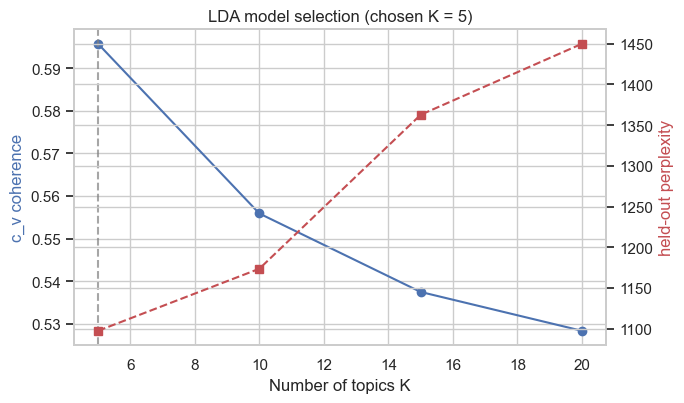

In [8]:
# coherence (left axis) and perplexity (right axis) vs K
fig, ax1 = plt.subplots(figsize=(7, 4.2))
ax1.plot(sel["k"], sel["coherence_cv"], "o-", color="C0", label="c_v coherence")
ax1.set_xlabel("Number of topics K"); ax1.set_ylabel("c_v coherence", color="C0")
ax1.axvline(K, ls="--", color="grey", alpha=.7)
ax2 = ax1.twinx()
ax2.plot(sel["k"], sel["perplexity"], "s--", color="C3", label="perplexity")
ax2.set_ylabel("held-out perplexity", color="C3")
ax1.set_title(f"LDA model selection (chosen K = {K})")
fig.tight_layout(); fig.savefig(f"{FIG}/lda_selection.png", dpi=150); plt.show()

Refit LDA at the chosen K on the full corpus, save the per-document topic matrix **θ**, and print
the top-10 words per topic.

In [9]:
lda = tp.refit_full(dictionary, corpus, K, passes=8)
theta = tp.topic_distribution_matrix(lda, corpus, K)
with open(f"{PROC}/theta.pkl", "wb") as f:
    pickle.dump(theta, f)

topic_words = tp.top_words(lda, K, topn=10)
print(f"θ matrix shape: {theta.shape}  (rows = docs, cols = K)")
for t, ws in topic_words.items():
    print(f"  Topic {t:>2}: {', '.join(ws)}")

θ matrix shape: (56390, 5)  (rows = docs, cols = K)
  Topic  0: collection, validation, original, provide, request, alleged, creditor, fdcpa, proof, collect
  Topic  1: report, reporting, information, fcra, inaccurate, collection, reported, dispute, identity, agency
  Topic  2: payment, mortgage, loan, bank, insurance, escrow, year, home, month, time
  Topic  3: call, received, never, time, sent, called, year, phone, number, collection
  Topic  4: violation, law, action, legal, practice, financial, notice, federal, without, right


Build the interactive pyLDAvis topic map and save it as HTML for the appendix.

In [10]:
# pyLDAvis interactive map (best-effort; saved as HTML for the appendix)
try:
    import pyLDAvis, pyLDAvis.gensim_models as gv
    vis = gv.prepare(lda, corpus, dictionary, sort_topics=False)
    pyLDAvis.save_html(vis, f"{FIG}/ldavis.html")
    print("saved ldavis.html")
except Exception as e:
    print("pyLDAvis skipped:", e)

saved ldavis.html


Render a word cloud for each topic as a visual summary of its top terms.

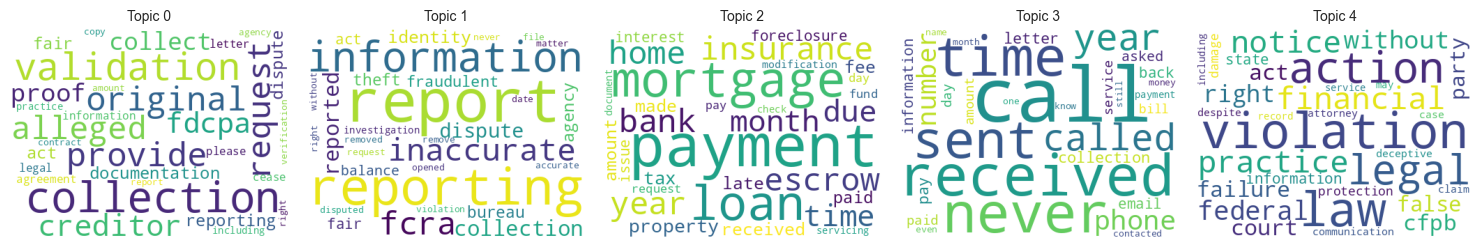

In [11]:
# per-topic wordclouds
from wordcloud import WordCloud
ncol = 5; nrow = int(np.ceil(K / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3 * ncol, 2.6 * nrow))
for ax in np.ravel(axes): ax.axis("off")
for t in range(K):
    freqs = dict(lda.show_topic(t, topn=30))
    wc = WordCloud(width=400, height=300, background_color="white").generate_from_frequencies(freqs)
    ax = np.ravel(axes)[t]; ax.imshow(wc); ax.set_title(f"Topic {t}", fontsize=10)
fig.tight_layout(); fig.savefig(f"{FIG}/topic_wordclouds.png", dpi=150); plt.show()

## §E - LSA comparison

Compare LDA against the classical linear alternative, Latent Semantic Analysis.

Fit TF-IDF → `TruncatedSVD` (LSA) with the same number of components as the chosen K, and score it
with the **same c_v coherence** so the LDA-vs-LSA comparison is fair.

In [12]:
svd, vec, lsa_words = tp.fit_lsa(tokens, n_components=K)
lda_coh = tp.coherence_of_topics(topic_words, tokens, dictionary)
lsa_coh = tp.coherence_of_topics(lsa_words, tokens, dictionary)

cmp = pd.DataFrame({
    "method": ["LDA", "LSA"],
    "components": [K, K],
    "coherence_cv": [round(lda_coh, 4), round(lsa_coh, 4)],
})
cmp.to_csv(f"{TAB}/lda_vs_lsa.csv", index=False)
print(cmp.to_string(index=False))
print("\nLSA top words (note frequent sign-mixed / less separable components):")
for c in range(min(K, 5)):
    print(f"  Comp {c}: {', '.join(lsa_words[c])}")

method  components  coherence_cv
   LDA           5        0.6525
   LSA           5        0.4877

LSA top words (note frequent sign-mixed / less separable components):
  Comp 0: collection, reporting, report, information, validation, request, original, provide, dispute, creditor
  Comp 1: payment, mortgage, loan, reporting, call, time, validation, called, year, paid
  Comp 2: report, reporting, identity, falsely, validation, theft, original, fraudulent, information, alleged
  Comp 3: falsely, reporting, payment, identity, mortgage, report, theft, violation, please, act
  Comp 4: falsely, payment, call, collector, never, number, mortgage, phone, research, collection


## §F - Feature engineering

Build the supervised feature matrix with **≥ 4 inputs and a single output `y`**.

Assemble X = topic proportions θ + four text signals (VADER sentiment, document length,
complaint-lexicon count, urgency-marker count) + **leakage-safe one-hot categoricals** (product,
sub-product, submission channel - all known at complaint time). This gives well over the required
4 inputs and a single output `y`. Standardisation is applied later **inside the train split** (§G)
to avoid leakage.

In [13]:
X = ft.build_features(theta, df, tokens)
y = df["y"].reset_index(drop=True)
X.to_pickle(f"{PROC}/X.pkl"); y.to_pickle(f"{PROC}/y.pkl")

print(f"X shape: {X.shape}  ({X.shape[1]} predictors)  | NaNs: {int(X.isna().sum().sum())}")
print("continuous features:\n", X[[f'theta_{i}' for i in range(K)] + ft.NUMERIC_FEATURES]
      .describe().round(3).T.to_string())

X shape: (56390, 23)  (23 predictors)  | NaNs: 0
continuous features:
                      count    mean      std  min     25%     50%      75%       max
theta_0            56390.0   0.201    0.289  0.0   0.003   0.021    0.318     0.998
theta_1            56390.0   0.220    0.301  0.0   0.003   0.040    0.364     0.998
theta_2            56390.0   0.149    0.259  0.0   0.002   0.005    0.174     0.997
theta_3            56390.0   0.334    0.336  0.0   0.011   0.226    0.614     0.998
theta_4            56390.0   0.096    0.165  0.0   0.002   0.006    0.128     0.996
sentiment          56390.0  -0.217    0.682 -1.0  -0.862  -0.407    0.420     1.000
doc_length         56390.0  92.723  112.651  0.0  29.000  63.000  118.000  2742.000
complaint_lexicon  56390.0   4.440    5.374  0.0   1.000   3.000    6.000   133.000
urgency_markers    56390.0   2.623    4.008  0.0   0.000   1.000    3.000   137.000


Visualise feature structure: a correlation heatmap over the continuous features (θ + text signals),
and how the four engineered text features differ between the relief and no-relief classes.

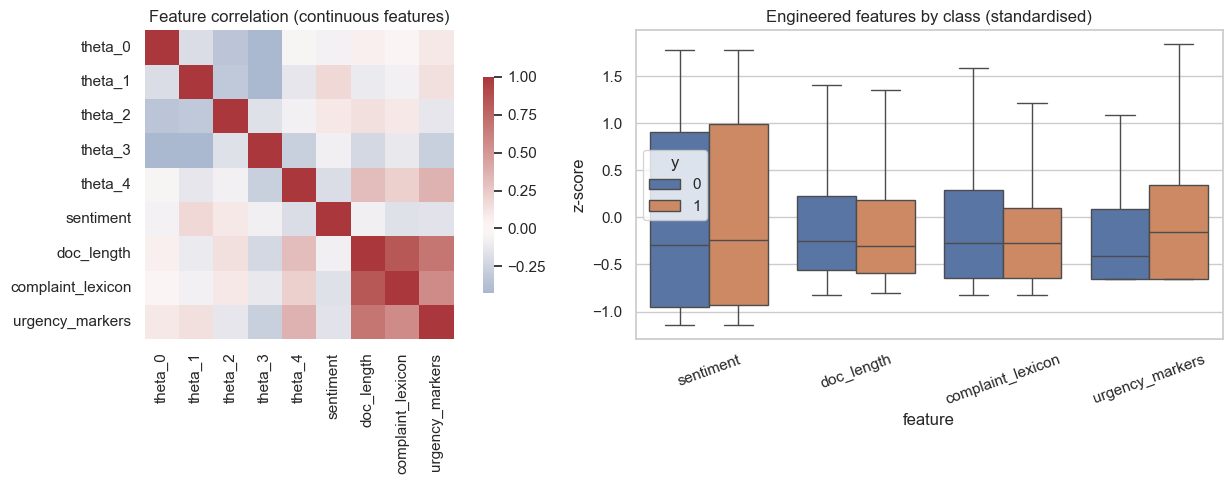

In [14]:
# Feature EDA: correlation structure + engineered features split by class
num_cols = [f"theta_{i}" for i in range(K)] + ft.NUMERIC_FEATURES
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(X[num_cols].corr(), ax=ax[0], cmap="vlag", center=0, square=True, cbar_kws={"shrink": .7})
ax[0].set_title("Feature correlation (continuous features)")

eng = ft.NUMERIC_FEATURES
Xe = X[eng].copy(); Xe["y"] = y.values
melt = Xe.melt(id_vars="y", var_name="feature", value_name="val")
melt["z"] = melt.groupby("feature")["val"].transform(lambda s: (s - s.mean()) / (s.std() + 1e-9))
sns.boxplot(data=melt, x="feature", y="z", hue="y", ax=ax[1], showfliers=False)
ax[1].set_title("Engineered features by class (standardised)")
ax[1].set_ylabel("z-score"); ax[1].tick_params(axis="x", rotation=20)
fig.tight_layout(); fig.savefig(FIG / "feature_eda.png", dpi=150); plt.show()

## §G - Gaussian Process classification via thresholding

GP classification the assignment's way: threshold a GP **regression** posterior. The GP runs on a
stratified subsample because it is O(n³) in time / O(n²) in memory - a GP on the full corpus is
infeasible.

Draw a stratified ~4K subsample, split train/test, standardise (scaler fit on train only), fit a GP
regressor with **RBF** and **Matérn** kernels, then threshold the predicted mean (tuned on training
scores by macro-F1) into class labels. `return_std` gives per-prediction uncertainty.

In [15]:
GP_SAMPLE = 4_000   # GP is O(n^3); 4K + a capped optimiser keeps the fit to a few minutes
Xs, ys = ev.stratified_sample(X, y, GP_SAMPLE)
X_tr, X_te, y_tr, y_te = train_test_split(
    Xs, ys, test_size=0.2, stratify=ys, random_state=RANDOM_STATE)

scaler = ev.fit_scaler(X_tr)
X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
print(f"GP sample: {len(Xs):,}  (train {len(X_tr):,} / test {len(X_te):,}) | "
      f"train positive {y_tr.mean()*100:.1f}%")

import time as _t
gp_out = {}
for name, kernel in ev.make_kernels().items():
    _t0 = _t.time()
    print(f"  fitting GP-{name} (O(n^3); the slow step, ~2-3 min) ...", flush=True)
    gp = ev.fit_gp(X_tr_s, y_tr, kernel, n_restarts_optimizer=0)
    prob_tr, _ = ev.gp_predict_proba(gp, X_tr_s)
    prob_te, std_te = ev.gp_predict_proba(gp, X_te_s)
    thr, f1_tr = ev.tune_threshold(y_tr.values, prob_tr)
    gp_out[name] = dict(gp=gp, prob=prob_te, std=std_te, thr=thr,
                        pred=(prob_te >= thr).astype(int))
    print(f"  GP-{name:7s} done in {_t.time()-_t0:.0f}s: threshold={thr:.2f}  "
          f"mean_std={std_te.mean():.3f}  learned_kernel={gp.kernel_}")

GP sample: 4,000  (train 3,200 / test 800) | train positive 17.8%
  fitting GP-RBF (O(n^3); the slow step, ~2-3 min) ...
  GP-RBF     done in 77s: threshold=0.24  mean_std=0.374  learned_kernel=0.297**2 * RBF(length_scale=5.46) + WhiteKernel(noise_level=0.945)
  fitting GP-Matern (O(n^3); the slow step, ~2-3 min) ...
  GP-Matern  done in 62s: threshold=0.24  mean_std=0.373  learned_kernel=0.312**2 * Matern(length_scale=6.54, nu=1.5) + WhiteKernel(noise_level=0.94)


## §H - SVM baseline

A strong discriminative baseline to compare against the GP.

Tune an RBF `SVC` (class-weighted) with `GridSearchCV` on the **same split**, then refit with
`probability=True` so its probabilities are comparable in the calibration analysis.

In [16]:
svm, best = ev.fit_svm(X_tr_s, y_tr)
svm_prob = svm.predict_proba(X_te_s)[:, 1]
svm_pred = svm.predict(X_te_s)
print("Best SVM params:", best)

Best SVM params: {'C': 1.0, 'gamma': 'scale'}


## §I - Evaluation & calibration

Compare the models on discrimination and, crucially, on probability calibration - the paper's
headline contribution.

Compute accuracy, balanced accuracy, macro-F1, AUC, Brier score and ECE for both models on the
held-out test set, and pick the best GP kernel by AUC.

In [17]:
rows = {}
for name in gp_out:
    o = gp_out[name]
    rows[f"GP-{name}"] = ev.compute_metrics(y_te, o["prob"], o["pred"])
rows["SVM"] = ev.compute_metrics(y_te, svm_prob, svm_pred)
metrics = pd.DataFrame(rows).T.round(4)
metrics.to_csv(f"{TAB}/metrics.csv")
print(metrics.to_string())

best_gp = max(gp_out, key=lambda n: rows[f"GP-{n}"]["roc_auc"])
print(f"\nBest GP kernel by AUC: {best_gp}")

           accuracy  balanced_accuracy  precision_macro  recall_macro  f1_macro  roc_auc  pr_auc   brier     ece
GP-RBF       0.7175             0.5632           0.5538        0.5632    0.5565   0.6426  0.2634  0.1407  0.0275
GP-Matern    0.7062             0.5646           0.5519        0.5646    0.5544   0.6419  0.2590  0.1409  0.0198
SVM          0.5875             0.6029           0.5605        0.6029    0.5241   0.6369  0.2389  0.1422  0.0331

Best GP kernel by AUC: RBF


Overlay the ROC curves to compare discrimination between the GP kernels and the SVM.

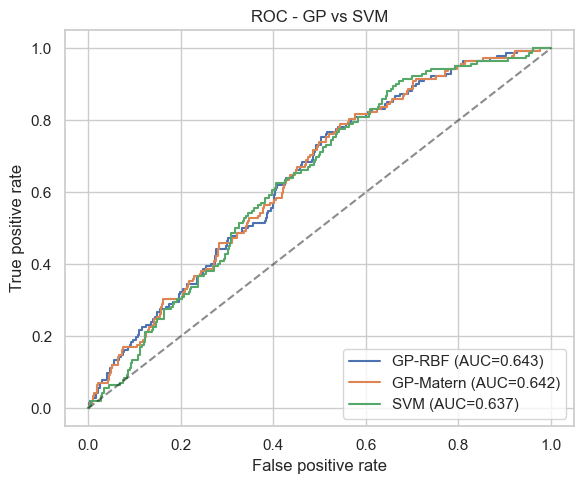

In [18]:
from sklearn.metrics import roc_curve
fig, ax = plt.subplots(figsize=(6, 5))
for name in gp_out:
    fpr, tpr, _ = roc_curve(y_te, gp_out[name]["prob"])
    ax.plot(fpr, tpr, label=f"GP-{name} (AUC={rows[f'GP-{name}']['roc_auc']:.3f})")
fpr, tpr, _ = roc_curve(y_te, svm_prob)
ax.plot(fpr, tpr, label=f"SVM (AUC={rows['SVM']['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=.5)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC - GP vs SVM"); ax.legend(loc="lower right")
fig.tight_layout(); fig.savefig(f"{FIG}/roc.png", dpi=150); plt.show()

Plot reliability diagrams to compare how well-calibrated each model's predicted probabilities are
(the GP is expected to sit closer to the diagonal).

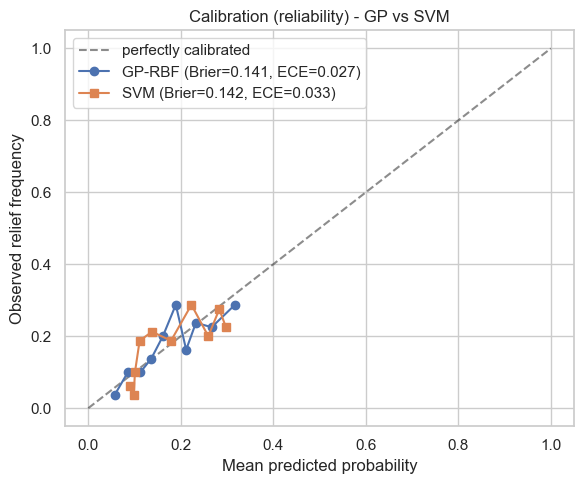

In [19]:
from sklearn.calibration import calibration_curve
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", alpha=.5, label="perfectly calibrated")
gp = gp_out[best_gp]
yp, xp = calibration_curve(y_te, gp["prob"], n_bins=10, strategy="quantile")
ax.plot(xp, yp, "o-", label=f"GP-{best_gp} (Brier={rows[f'GP-{best_gp}']['brier']:.3f}, "
                            f"ECE={rows[f'GP-{best_gp}']['ece']:.3f})")
yp, xp = calibration_curve(y_te, svm_prob, n_bins=10, strategy="quantile")
ax.plot(xp, yp, "s-", label=f"SVM (Brier={rows['SVM']['brier']:.3f}, "
                            f"ECE={rows['SVM']['ece']:.3f})")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed relief frequency")
ax.set_title("Calibration (reliability) - GP vs SVM"); ax.legend(loc="upper left")
fig.tight_layout(); fig.savefig(f"{FIG}/calibration.png", dpi=150); plt.show()

Show confusion matrices and per-class precision/recall/F1 for the best GP and the SVM.

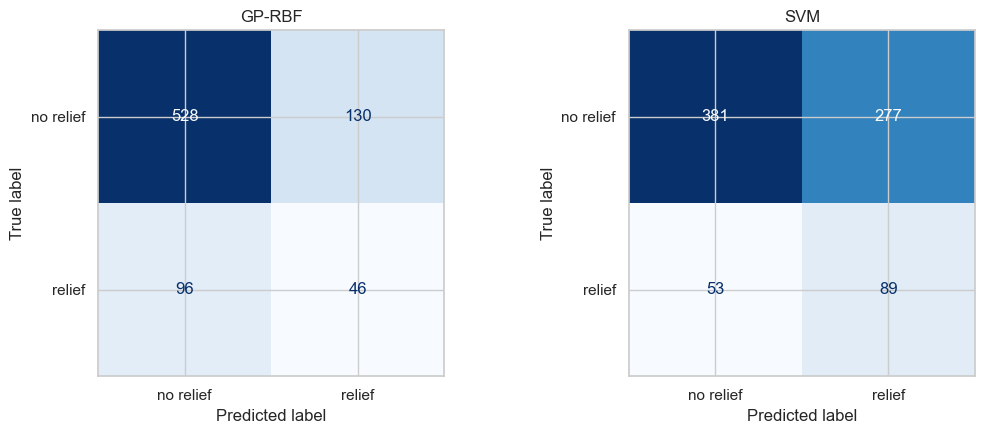

=== GP-RBF ===
              precision    recall  f1-score   support

   no relief       0.85      0.80      0.82       658
      relief       0.26      0.32      0.29       142

    accuracy                           0.72       800
   macro avg       0.55      0.56      0.56       800
weighted avg       0.74      0.72      0.73       800

=== SVM ===
              precision    recall  f1-score   support

   no relief       0.88      0.58      0.70       658
      relief       0.24      0.63      0.35       142

    accuracy                           0.59       800
   macro avg       0.56      0.60      0.52       800
weighted avg       0.77      0.59      0.64       800



In [20]:
# Confusion matrices + per-class classification reports (best GP vs SVM)
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
pairs = [(f"GP-{best_gp}", gp_out[best_gp]["pred"]), ("SVM", svm_pred)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, pairs):
    ConfusionMatrixDisplay(confusion_matrix(y_te, pred),
                           display_labels=["no relief", "relief"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
fig.tight_layout(); fig.savefig(f"{FIG}/confusion_matrices.png", dpi=150); plt.show()

for name, pred in pairs:
    print(f"=== {name} ===")
    print(classification_report(y_te, pred, target_names=["no relief", "relief"], zero_division=0))

**k-fold cross-validation.** A single split can be lucky; we repeat the best-GP and the SVM over 5
stratified folds of the GP sample and report **mean ± std**. This is the honest, rigorous way to
compare two models whose single-split gaps are within noise.

In [21]:
cv = ev.cross_validate_eval(Xs, ys, kernel_name=best_gp, n_splits=5)
cv.to_csv(f"{TAB}/metrics_cv.csv", index=False)
cv_summary = (cv.groupby("model")[["f1_macro", "roc_auc", "pr_auc", "brier", "ece"]]
                .agg(["mean", "std"]).round(4))
print("5-fold CV (mean / std):")
print(cv_summary.to_string())

    fold 1/5 done
    fold 2/5 done
    fold 3/5 done
    fold 4/5 done
    fold 5/5 done
5-fold CV (mean / std):
       f1_macro         roc_auc          pr_auc           brier             ece        
           mean     std    mean     std    mean     std    mean     std    mean     std
model                                                                                  
GP-RBF   0.5733  0.0123  0.6650  0.0209  0.2731  0.0197  0.1395  0.0017  0.0200  0.0105
SVM      0.5260  0.0103  0.6542  0.0287  0.2648  0.0266  0.1403  0.0018  0.0206  0.0076


**Selective prediction (the GP-uncertainty payoff).** Rank test cases by the GP's posterior std and
keep only the most-confident fraction ("coverage"); if the uncertainty is meaningful, accuracy and
macro-F1 should *rise* as we abstain on the least-confident cases - a capability the SVM lacks.

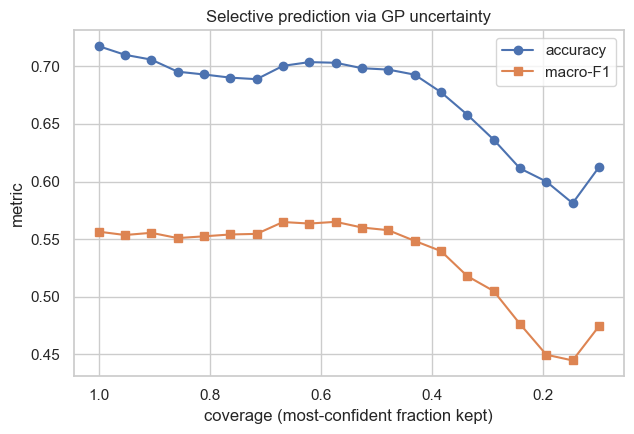

accuracy: 0.718 @100% coverage  ->  0.613 @ 10% coverage


In [22]:
cov, accs, f1s = ev.risk_coverage(
    y_te.values, gp_out[best_gp]["prob"], gp_out[best_gp]["std"], gp_out[best_gp]["thr"])
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(cov, accs, "o-", label="accuracy"); ax.plot(cov, f1s, "s-", label="macro-F1")
ax.invert_xaxis()
ax.set_xlabel("coverage (most-confident fraction kept)"); ax.set_ylabel("metric")
ax.set_title("Selective prediction via GP uncertainty"); ax.legend()
fig.tight_layout(); fig.savefig(f"{FIG}/risk_coverage.png", dpi=150); plt.show()
print(f"accuracy: {accs[0]:.3f} @100% coverage  ->  {accs[-1]:.3f} @ {cov[-1]*100:.0f}% coverage")

**Error analysis.** A couple of false positives and false negatives from the test set (with narrative
snippets) to see where the model struggles.

In [23]:
test_df = df.iloc[X_te.index].reset_index(drop=True)
test_df["prob"] = gp_out[best_gp]["prob"]; test_df["pred"] = gp_out[best_gp]["pred"]
test_df["actual"] = y_te.values
snip = lambda t: (str(t)[:150] + " ...")
for label, mask in [("False positives (predicted relief, actually none)",
                     (test_df.pred == 1) & (test_df.actual == 0)),
                    ("False negatives (predicted none, actually relief)",
                     (test_df.pred == 0) & (test_df.actual == 1))]:
    print(f"\n{label}:")
    for _, r in test_df[mask].head(2).iterrows():
        print(f"  P(relief)={r['prob']:.2f} | {snip(r['narrative'])}")


False positives (predicted relief, actually none):
  P(relief)=0.25 | I am writing to express my dissatisfaction with the service provided towards me about fixing a serious problem over my credit report. I have contacted ...
  P(relief)=0.30 | I will go into detail below but the just of this is that I have had ongoing issues with Fifth Third Bank for going on 5 years and they have been horri ...

False negatives (predicted none, actually relief):
  P(relief)=0.13 | MIDLAND CREDIT MANAGEM is falsely reporting on my credit. I have never had any accounts with them. Per my research MIDLAND CREDIT MANAGEM is a debt co ...
  P(relief)=0.11 | I need Mr. Cooper to adjust my escrow balance to the correct value, as its wrongly showing a negative balance of XXXX due to two duplicated hazard ins ...


## §J - Decision-support demo

A light, illustrative ranking output - the system is decision *support*, not autonomous.

Rank held-out complaints by GP relief-probability (with the GP's uncertainty), and plot overall
topic prevalence across the corpus.

Top-10 complaints by GP relief-probability:
      relief_prob  uncertainty_std  actual_y  sentiment  urgency_markers
585         0.363            0.373         0      0.803                2
1538        0.363            0.373         1      0.908                6
3302        0.358            0.373         1      0.898                4
669         0.358            0.373         0      0.965                6
2896        0.358            0.373         1      0.557                1
1927        0.357            0.374         0      0.967               10
3090        0.356            0.374         0      0.867                5
1575        0.356            0.373         0      0.909                4
1138        0.354            0.373         0      0.382                2
1572        0.347            0.373         1     -0.036                1


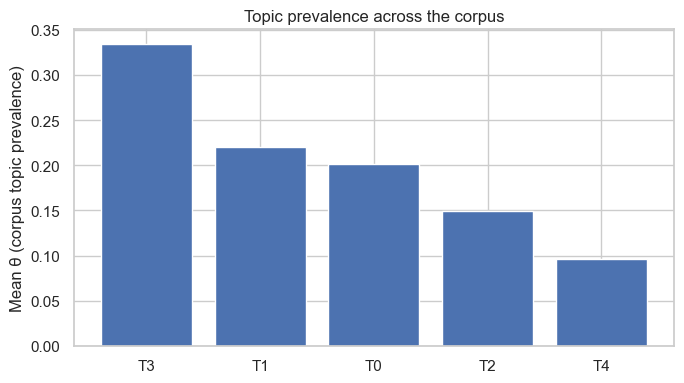

In [24]:
best = gp_out[best_gp]
demo = X_te.copy()
demo["relief_prob"] = best["prob"]; demo["uncertainty_std"] = best["std"]; demo["actual_y"] = y_te.values
top = demo.sort_values("relief_prob", ascending=False).head(10)
print("Top-10 complaints by GP relief-probability:")
print(top[["relief_prob", "uncertainty_std", "actual_y", "sentiment", "urgency_markers"]]
      .round(3).to_string())

prevalence = theta.mean(axis=0)
fig, ax = plt.subplots(figsize=(7, 4))
order = np.argsort(prevalence)[::-1]
ax.bar([f"T{t}" for t in order], prevalence[order], color="C0")
ax.set_ylabel("Mean θ (corpus topic prevalence)"); ax.set_title("Topic prevalence across the corpus")
fig.tight_layout(); fig.savefig(f"{FIG}/topic_prevalence.png", dpi=150); plt.show()

**Topic ↔ relief.** Relief rate by *dominant* LDA topic - this links the unsupervised topics back to
the supervised outcome, showing which complaint themes are most/least likely to win relief.

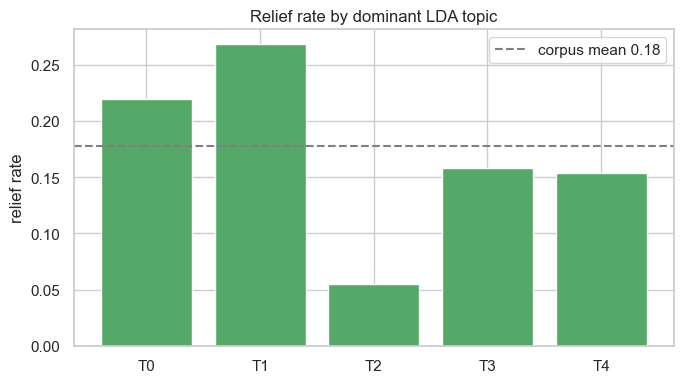

       relief_rate      n
topic                    
0            0.220  11184
1            0.268  12308
2            0.055   8873
3            0.158  20038
4            0.154   3987

Pipeline complete - all figures/tables written to results/.


In [25]:
dom = theta.argmax(axis=1)
tr = (pd.DataFrame({"topic": dom, "y": y.values})
        .groupby("topic")["y"].agg(relief_rate="mean", n="size"))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f"T{t}" for t in tr.index], tr["relief_rate"], color="C2")
ax.axhline(y.mean(), ls="--", color="grey", label=f"corpus mean {y.mean():.2f}")
ax.set_ylabel("relief rate"); ax.set_title("Relief rate by dominant LDA topic"); ax.legend()
fig.tight_layout(); fig.savefig(f"{FIG}/topic_relief.png", dpi=150); plt.show()
print(tr.assign(relief_rate=tr["relief_rate"].round(3)).to_string())
print("\nPipeline complete - all figures/tables written to results/.")

## §K - End-to-end single-complaint inference

The capstone test: feed **one raw complaint narrative** through the *whole* trained pipeline and
return everything the system promises - the dominant LDA topic (with its top words), the full topic
distribution θ, the engineered features, and the **escalation-risk decision**: the GP's calibrated
relief-probability with its uncertainty, thresholded into a recommendation, alongside the SVM's
probability for comparison. This is decision *support* - a human reviewer makes the final call.

Define `predict_complaint(text)`, which reuses the already-fitted LDA model, scaler, GP and SVM to
score a single narrative end-to-end.

In [26]:
def predict_complaint(text, meta=None, threshold=None):
    # 1) preprocess -> tokens, then LDA topic distribution theta (1 x K)
    toks = pp.preprocess_corpus([text])
    bow = dictionary.doc2bow(toks[0])
    theta_vec = np.zeros((1, K), dtype=np.float32)
    for tid, p in lda.get_document_topics(bow, minimum_probability=0.0):
        theta_vec[0, tid] = p

    # 2) build the same feature vector as training. build_features expects a DataFrame with the
    #    narrative + categorical columns; for a single complaint we use the supplied metadata
    #    (or "missing"), then REINDEX to the trained X columns so the one-hot layout matches.
    row = {"narrative": text}
    for col in ["product", "subproduct", "submitted_via", "issue", "subissue"]:
        row[col] = (meta or {}).get(col, "missing")
    one_df = pd.DataFrame([row])
    Xone = ft.build_features(theta_vec, one_df, toks).reindex(columns=X.columns, fill_value=0.0)
    Xone_s = scaler.transform(Xone)

    # 3) GP relief-probability + uncertainty, thresholded into a decision
    gp = gp_out[best_gp]["gp"]
    prob, std = ev.gp_predict_proba(gp, Xone_s)
    thr = gp_out[best_gp]["thr"] if threshold is None else threshold
    gp_p, gp_sd = float(prob[0]), float(std[0])
    decision = "RELIEF likely -> prioritise/escalate" if gp_p >= thr else "No relief likely"

    # 4) SVM probability for comparison
    svm_p = float(svm.predict_proba(Xone_s)[0, 1])

    dom = int(theta_vec.argmax())
    return dict(tokens=toks[0], theta=theta_vec[0], dominant_topic=dom,
                features=Xone.iloc[0], gp_prob=gp_p, gp_std=gp_sd, threshold=thr,
                decision=decision, svm_prob=svm_p)


def show_prediction(text, meta=None):
    r = predict_complaint(text, meta)
    print("COMPLAINT:", (text[:240] + " ...") if len(text) > 240 else text)
    print(f"\nDominant topic  : T{r['dominant_topic']}  [{', '.join(topic_words[r['dominant_topic']][:8])}]")
    print("Topic mix theta : " + "  ".join(f"T{i}={p:.2f}" for i, p in enumerate(r['theta'])))
    print(f"Key features    : sentiment={r['features']['sentiment']:.2f}, "
          f"len={int(r['features']['doc_length'])}, "
          f"urgency={int(r['features']['urgency_markers'])}, "
          f"complaint_cues={int(r['features']['complaint_lexicon'])}")
    print(f"\nGP  P(relief)   : {r['gp_prob']:.3f}  +/- {r['gp_std']:.3f} (uncertainty)   "
          f"[threshold {r['threshold']:.2f}]")
    print(f"SVM P(relief)   : {r['svm_prob']:.3f}")
    print(f"DECISION        : {r['decision']}")
    return r

Run it on a **real held-out complaint** (so we can compare against the recorded outcome) and on a
**hand-written urgent complaint** to see the pipeline respond to escalation cues.

In [27]:
# (a) a real held-out complaint with its recorded outcome (pass its real metadata)
idx = X_te.index[0]
real_text = df["narrative"].iloc[idx]
real_meta = {c: df[c].iloc[idx] for c in ["product", "subproduct", "submitted_via"]
             if c in df.columns}
print("=== (a) Real held-out complaint ===")
show_prediction(real_text, real_meta)
print(f"\nACTUAL recorded outcome: y={int(y.iloc[idx])}  "
      f"({'relief' if y.iloc[idx]==1 else 'no relief'})")

# (b) a hand-written complaint with strong escalation language
print("\n\n=== (b) Hand-written complaint ===")
demo_text = ("I have disputed this debt collection charge three times and the company keeps "
             "ignoring me. This is fraud. I have contacted my attorney and will file a lawsuit "
             "if this unauthorized fee is not refunded immediately.")
show_prediction(demo_text)

=== (a) Real held-out complaint ===
COMPLAINT: I closed on a XXXX XXXX  in XXXX, CA on XX/XX/2024. Throughout the purchase process, over a year, I was told by XXXX XXXX I have the option to lease or buy my solar panels for {$15000.00}. Buying was always my choice. XXXX XXXX reps consist ...

Dominant topic  : T2  [payment, mortgage, loan, bank, insurance, escrow, year, home]
Topic mix theta : T0=0.00  T1=0.00  T2=0.76  T3=0.21  T4=0.02
Key features    : sentiment=0.38, len=103, urgency=0, complaint_cues=5

GP  P(relief)   : 0.035  +/- 0.375 (uncertainty)   [threshold 0.24]
SVM P(relief)   : 0.096
DECISION        : No relief likely

ACTUAL recorded outcome: y=0  (no relief)


=== (b) Hand-written complaint ===
COMPLAINT: I have disputed this debt collection charge three times and the company keeps ignoring me. This is fraud. I have contacted my attorney and will file a lawsuit if this unauthorized fee is not refunded immediately.

Dominant topic  : T3  [call, received, never, time, sent

{'tokens': ['disputed',
  'debt',
  'collection',
  'charge',
  'three',
  'time',
  'keep',
  'ignoring',
  'fraud',
  'contacted',
  'attorney',
  'file',
  'lawsuit',
  'unauthorized',
  'fee',
  'refunded',
  'immediately'],
 'theta': array([0.00839367, 0.25774476, 0.00570876, 0.72226965, 0.00588322],
       dtype=float32),
 'dominant_topic': 3,
 'features': theta_0                                   0.008394
 theta_1                                   0.257745
 theta_2                                   0.005709
 theta_3                                   0.722270
 theta_4                                   0.005883
 sentiment                                -0.913100
 doc_length                               17.000000
 complaint_lexicon                         3.000000
 urgency_markers                           4.000000
 product_Debt collection                   0.000000
 product_Mortgage                          0.000000
 submitted_via_Web                         0.000000
 subproduct_